In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.append(r'c:/Users/sebas/MalariaProject/src')

from src import Plotter, KMCParams_v4, LatticeSOS_v4, KMC_BKL_v4

In [27]:
import pandas as pd

archivo = r"C:\Users\sebas\MalariaProject\data\beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

In [28]:
#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

In [8]:
params_v4 = KMCParams_v4(
    #T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [29]:
params_v4_2 = KMCParams_v4(
    #T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=0.76085943,
    E_pb_over_kT_y=2.19936039,
    phi_over_kT=1.4792478012079329,
    delta_x= 0.63,#1.7789686274068774,
    delta_y=0.30,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [35]:
L = LatticeSOS_v4(size=[45, 45], seed=42)
L.initialize("flat")

kmc_v4 = KMC_BKL_v4(L, params_v4_2, N_bulk0=3000, rng_seed=123, time_scale=200, n_seeds=200)
#kmc1 = KMC_BKL_v4(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL_v4(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps, stats = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (45, 45): 28.180 minutos


In [39]:
L = LatticeSOS_v4(size=[55, 55], seed=42)
L.initialize("flat")

kmc_v4 = KMC_BKL_v4(L, params_v4_2, N_bulk0=2000, rng_seed=123, time_scale=400, n_seeds=200)
#kmc1 = KMC_BKL_v4(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL_v4(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps, stats = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (55, 55): 25.381 minutos


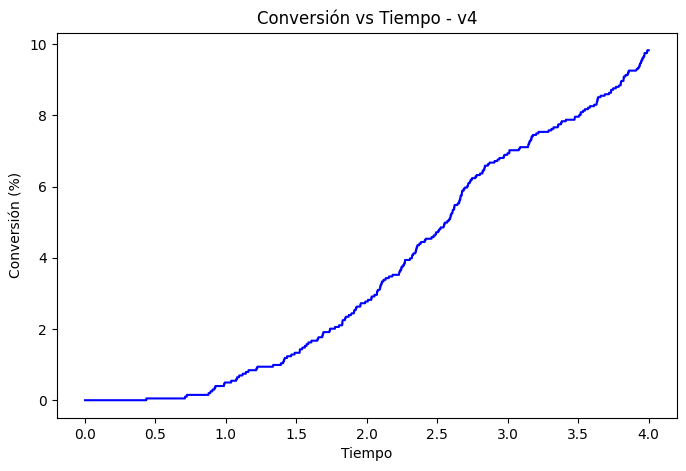

In [40]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_v4)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - v4")

In [41]:
#plots = Plotter(kmc_v4)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

#plots.plot_conversion(snaps[0], title=f"Conversión vs Tiempo - S = 2")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
plots.crystal_growth_gif(snaps, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1_1.gif", title_prefix = f"Crystal Growth - S=2")
    

💾 GIF guardado en: c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1_1.gif


In [5]:
params = KMCParams(
    T=300,
    K0_plus=0.211,
    K_inc_plus=0.0,
    E_pb_over_kT=0.48,
    phi_over_kT= 3.76,
    delta=2.63,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

params1 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

params2 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=0.35*1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

times = times_txt

In [ ]:
L = LatticeSOS(size=[25, 25], seed=42)
L.initialize("flat")

kmc = KMC_BKL(L, params1, N_bulk0=2000, rng_seed=123, time_scale=70, n_seeds=100)
#kmc1 = KMC_BKL(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps = kmc.run(t_end=times[-1], snapshot_times=times)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")

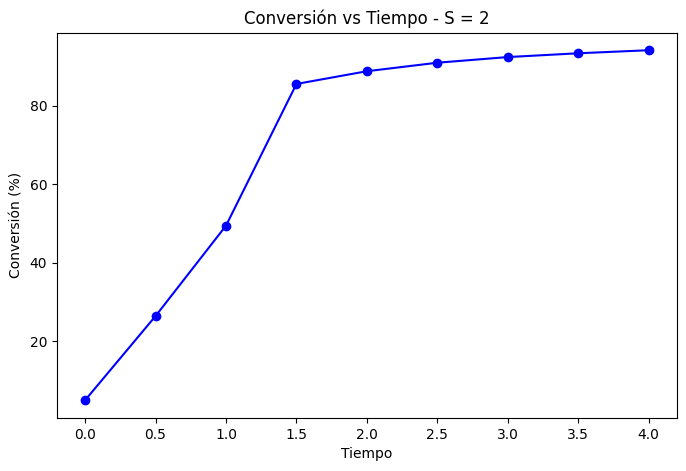

In [11]:
plots = Plotter(kmc)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

plots.plot_conversion(snaps, title=f"Conversión vs Tiempo - S = 2")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
#plots2.crystal_growth_gif(snaps2, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1.gif", title_prefix = f"Crystal Growth - S=2")
    

# Paso 1: Barrido fixed_sigma para X(t), J2D y W(t)

In [9]:
# Helpers para observables 3D (postproceso).
def occupied_mask_3d(heights):
    # Footprint proyectada del cristal.
    return heights > 0

def extent_lengths_from_mask(mask):
    # Longitudes en x/y de la caja envolvente.
    coords = np.argwhere(mask)
    if coords.size == 0:
        return 0, 0
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    return int(x_max - x_min + 1), int(y_max - y_min + 1)

def aspect_ratio_from_mask(mask):
    # Cociente L/W usando la caja envolvente.
    lx, ly = extent_lengths_from_mask(mask)
    if lx == 0 or ly == 0:
        return 0.0
    return float(max(lx, ly)) / float(min(lx, ly))

def anisotropy_from_snapshots(mask0, t0, mask1, t1):
    # Estima vx, vy desde cambios de extension.
    dt = max(float(t1 - t0), 1e-12)
    lx0, ly0 = extent_lengths_from_mask(mask0)
    lx1, ly1 = extent_lengths_from_mask(mask1)
    vx = (lx1 - lx0) / dt
    vy = (ly1 - ly0) / dt
    ratio = vx / vy if abs(vy) > 1e-12 else np.inf
    return float(vx), float(vy), float(ratio)

def surface_roughness(heights):
    # Rugosidad RMS.
    return float(np.std(heights))

def connected_components_4(mask):
    # Componentes conexas 4-vecinos (sin borde periodico).
    visited = np.zeros_like(mask, dtype=bool)
    comps = []
    nx, ny = mask.shape
    for i in range(nx):
        for j in range(ny):
            if not mask[i, j] or visited[i, j]:
                continue
            stack = [(i, j)]
            visited[i, j] = True
            comp = []
            while stack:
                x, y = stack.pop()
                comp.append((x, y))
                for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    xx = x + dx
                    yy = y + dy
                    if 0 <= xx < nx and 0 <= yy < ny and mask[xx, yy] and not visited[xx, yy]:
                        visited[xx, yy] = True
                        stack.append((xx, yy))
            comps.append(comp)
    return comps

def estimate_j2d_top_layer(snaps, min_size=4, min_persist=2):
    # Proxy de J2D: nuevas islas estables en la capa superior.
    if len(snaps) < 2:
        return 0.0
    area = float(snaps[0][1].size)
    times = [float(t) for t, _, _ in snaps]
    counts = []
    for _, heights, _ in snaps:
        top = int(np.max(heights))
        mask = heights == top
        comps = connected_components_4(mask)
        sizes = [len(c) for c in comps if len(c) >= min_size]
        counts.append(len(sizes))
    new_islands = 0
    for i in range(1, len(counts)):
        if counts[i] > counts[i - 1]:
            # Persistencia minima para evitar ruido.
            end = min(i + min_persist, len(counts))
            ok = True
            for j in range(i, end):
                if counts[j] < counts[i]:
                    ok = False
                    break
            if ok:
                new_islands += counts[i] - counts[i - 1]
    total_time = max(times[-1] - times[0], 1e-12)
    return float(new_islands) / (area * total_time)

def run_v4_sim(params, lattice_size, t_end, snapshot_times, seed=123):
    # Ejecuta una corrida con parametros fijos.
    lat = LatticeSOS_v4(size=[lattice_size, lattice_size], seed=seed)
    lat.initialize("flat")
    kmc = KMC_BKL_v4(
        lat,
        params,
        N_bulk0=2000,
        rng_seed=seed,
        time_scale=70,
        n_seeds=0,
        use_solvent=False,
    )
    snaps, stats = kmc.run(t_end=t_end, snapshot_times=snapshot_times)
    return snaps, stats

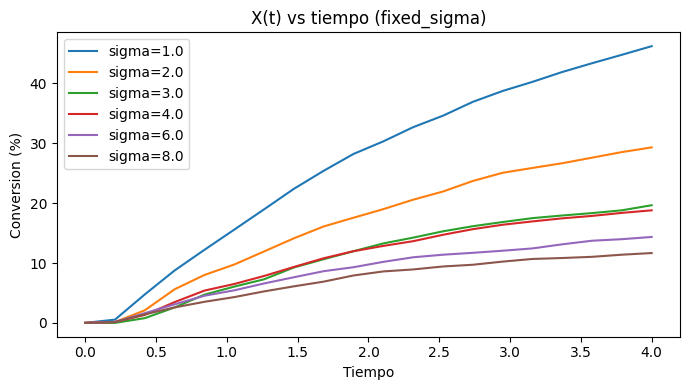

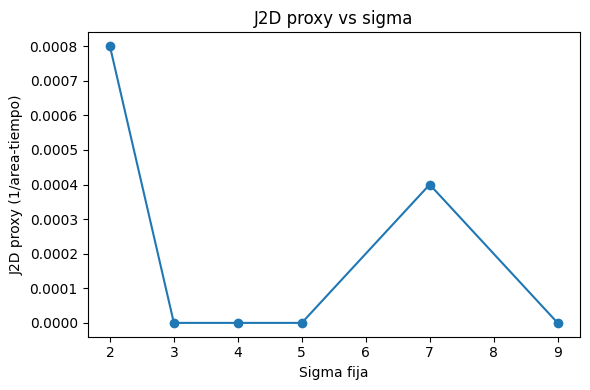

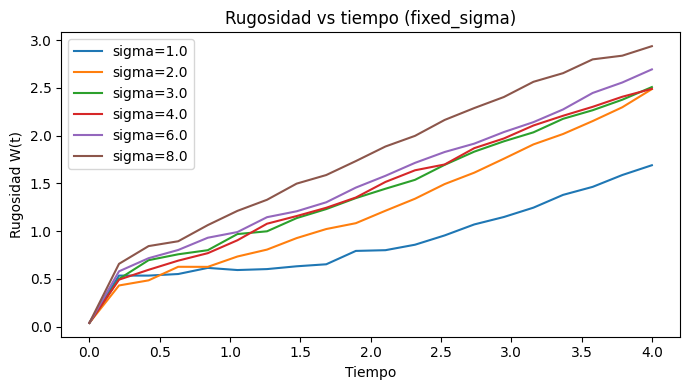

In [12]:
# Paso 1: barrido de fixed_sigma para X(t), J2D y W(t).
sigma_values = np.array([1.0, 2.0, 3.0, 4.0, 6.0, 8.0], dtype=float)
t_end = float(np.max(times_txt))
snapshot_times = np.linspace(0.0, t_end, 20)

sweep = []
for sigma in sigma_values:
    # Clona parametros base y fija sigma.
    base_dict = params_v4.__dict__.copy()
    base_dict["fixed_sigma"] = float(sigma)
    p_sigma = KMCParams_v4(**base_dict)

    # Ejecuta simulacion y extrae observables.
    snaps, stats = run_v4_sim(
        p_sigma,
        lattice_size=25,
        t_end=t_end,
        snapshot_times=snapshot_times,
        seed=123,
    )
    times = [t for t, _, _ in snaps]
    conv = [c for _, _, c in snaps]
    rough = [surface_roughness(h) for _, h, _ in snaps]
    j2d = estimate_j2d_top_layer(snaps, min_size=4, min_persist=2)

    sweep.append({
        "sigma": float(sigma),
        "times": times,
        "conversion": conv,
        "roughness": rough,
        "j2d": float(j2d),
    })

# Grafica X(t) para cada sigma.
plt.figure(figsize=(7, 4))
for item in sweep:
    plt.plot(item["times"], item["conversion"], label=f"sigma={item['sigma']:.1f}")
plt.xlabel("Tiempo")
plt.ylabel("Conversion (%)")
plt.title("X(t) vs tiempo (fixed_sigma)")
plt.legend()
plt.tight_layout()
plt.show()

# Grafica J2D vs sigma.
plt.figure(figsize=(6, 4))
plt.plot([(s["sigma"] + 1) for s in sweep], [s["j2d"] for s in sweep], marker="o")
plt.xlabel("Sigma fija")
plt.ylabel("J2D proxy (1/area-tiempo)")
plt.title("J2D proxy vs sigma")
plt.tight_layout()
plt.show()

# Grafica W(t) para cada sigma.
plt.figure(figsize=(7, 4))
for item in sweep:
    plt.plot(item["times"], item["roughness"], label=f"sigma={item['sigma']:.1f}")
plt.xlabel("Tiempo")
plt.ylabel("Rugosidad W(t)")
plt.title("Rugosidad vs tiempo (fixed_sigma)")
plt.legend()
plt.tight_layout()
plt.show()

# Paso 2: Ajuste de anisotropia para vx/vy y aspect ratio

In [11]:
# Paso 2: ajuste simple de anisotropia (delta_x/delta_y) para vx/vy.
target_ratio = 2.5
sigma_target = 4.0
ratio_factors = np.array([0.6, 0.8, 1.0, 1.2, 1.5, 1.8], dtype=float)
t_end_aniso = float(np.max(times_txt))
snapshot_times_aniso = np.linspace(0.0, t_end_aniso, 12)

results_aniso = []
for r in ratio_factors:
    # Ajuste anisotropico solo en delta_x/delta_y.
    base_dict = params_v4.__dict__.copy()
    base_dict["fixed_sigma"] = float(sigma_target)
    base_dict["delta_x"] = float(params_v4.delta_x * r)
    base_dict["delta_y"] = float(params_v4.delta_y / r)
    p_aniso = KMCParams_v4(**base_dict)

    # Ejecuta simulacion y mide anisotropia.
    snaps, stats = run_v4_sim(
        p_aniso,
        lattice_size=25,
        t_end=t_end_aniso,
        snapshot_times=snapshot_times_aniso,
        seed=123,
    )
    t0, h0, _ = snaps[0]
    t1, h1, _ = snaps[-1]
    mask0 = occupied_mask_3d(h0)
    mask1 = occupied_mask_3d(h1)
    vx, vy, ratio = anisotropy_from_snapshots(mask0, t0, mask1, t1)
    aspect = aspect_ratio_from_mask(mask1)

    results_aniso.append({
        "ratio_factor": float(r),
        "vx": float(vx),
        "vy": float(vy),
        "vx_over_vy": float(ratio),
        "aspect_ratio": float(aspect),
    })

# Selecciona el factor mas cercano al objetivo.
best = min(results_aniso, key=lambda x: abs(x["vx_over_vy"] - target_ratio))
print("Best ratio_factor:", best["ratio_factor"], "vx/vy:", best["vx_over_vy"], "aspect:", best["aspect_ratio"])

# Grafica vx/vy vs factor.
plt.figure(figsize=(6, 4))
plt.plot(
    [r["ratio_factor"] for r in results_aniso],
    [r["vx_over_vy"] for r in results_aniso],
    marker="o",
    label="vx/vy",
)
plt.axhline(target_ratio, color="red", linestyle="--", label="target")
plt.xlabel("delta_x / delta_y factor")
plt.ylabel("vx/vy")
plt.title("Anisotropia de avance vs factor")
plt.legend()
plt.tight_layout()
plt.show()

# Grafica aspect ratio vs factor.
plt.figure(figsize=(6, 4))
plt.plot(
    [r["ratio_factor"] for r in results_aniso],
    [r["aspect_ratio"] for r in results_aniso],
    marker="o",
)
plt.xlabel("delta_x / delta_y factor")
plt.ylabel("Aspect ratio")
plt.title("Aspect ratio vs anisotropia")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 